# Hidden Markov Model (HMM) Seasonal Analysis & Validation

## Objectives
1. **Load Labeled Training Data**: Analyze `data/rainfall/train/rainfall_10min_labeled.csv`, which contains 10-minute rainfall records and supervised `gmm_regime` labels.
2. **Climatological Profiling**: Resample to daily resolution (`Total Rainfall`, `Maximum Intensity`, `Rainy Fraction`), apply a 14-day rolling average to smooth seasonal variations, and compute the 365-day climatological profile across the 10-year period.
3. **Fit GaussianHMM**: Fit an unsupervised 4-state `GaussianHMM` on the climatological features.
4. **Label Validation**: Validate that the unsupervised HMM seasonal boundaries correspond to the supervised `gmm_regime` label column.
5. **Visualise Results**: Render the 3-panel climatological profile with background color shading representing the detected seasonal HMM states.
6. **Evaluate Synthetic Datasets**: Use the **same** trained HMM and feature scaler to predict and visualize seasonal behavior in synthetic generated datasets (`rainfall_synthetic_10y_v3.csv` and `rainfall_synthetic_10y_v4.csv`).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)


## 1. Data Loading & Preprocessing
We load `rainfall_10min_labeled.csv`, which contains 10-minute rainfall measurements and `gmm_regime` labels generated from 14-day storm block clustering.


In [2]:
print("Loading 10-minute labeled rainfall training dataset...")
df_train = pd.read_csv("../data/rainfall/train/rainfall_10min_labeled.csv")
df_train['date'] = pd.to_datetime(df_train['date'])
df_train.set_index('date', inplace=True)

print(f"Dataset shape: {df_train.shape}")
print(f"Date range: {df_train.index.min()} to {df_train.index.max()}")
print("\nFirst 5 rows:")
print(df_train.head())
print("\nRegime label (gmm_regime) value counts:")
print(df_train['gmm_regime'].value_counts().sort_index())


Loading 10-minute labeled rainfall training dataset...
Dataset shape: (419328, 3)
Date range: 2000-01-01 00:00:00 to 2009-12-21 23:50:00

First 5 rows:
                     avg_rainfall  block_id  gmm_regime
date                                                   
2000-01-01 00:00:00         0.005         0           2
2000-01-01 00:10:00         0.000         0           2
2000-01-01 00:20:00         0.000         0           2
2000-01-01 00:30:00         0.050         0           2
2000-01-01 00:40:00         0.020         0           2

Regime label (gmm_regime) value counts:
gmm_regime
0    106848
1    155232
2    116928
3     40320
Name: count, dtype: int64


## 2. Resampling & 14-Day Rolling Smoothing
Wwe resample the 10-minute data to daily features:
- **Total Rainfall**: Daily precipitation sum.
- **Maximum Intensity**: Maximum 10-minute rainfall recorded in the day.
- **Rainy Fraction**: Proportion of 10-minute intervals within the day recording non-zero rainfall.
- **gmm_regime**: Daily mode (most frequent regime label) of the 10-minute intervals.

We then apply a 14-day centered rolling average to smooth continuous rainfall features and capture overarching seasonal trends.


In [ ]:
# print("Resampling 10-minute intervals to daily features...")
# daily_features = pd.DataFrame({
#     'Total Rainfall': df_train['avg_rainfall'].resample('D').sum(),
#     'Maximum Intensity': df_train['avg_rainfall'].resample('D').max(),
#     'Rainy Fraction': df_train['avg_rainfall'].resample('D').apply(lambda x: (x > 0).mean()),
#     'gmm_regime': df_train['gmm_regime'].resample('D').apply(lambda x: x.mode()[0] if len(x)>0 and not x.isna().all() else None)
# }).dropna().copy()

# print(f"Daily samples: {len(daily_features)}")

# # Apply a 14-day rolling average to smooth continuous rainfall features
# smoothed_features = daily_features[['Total Rainfall', 'Maximum Intensity', 'Rainy Fraction']].rolling(window=14, center=True).mean().dropna()
# smoothed_features['gmm_regime'] = daily_features.loc[smoothed_features.index, 'gmm_regime']

# print(f"Smoothed daily samples: {len(smoothed_features)}")
# print("\nSmoothed features head:")
# print(smoothed_features.head())


Resampling 10-minute intervals to daily features...
Daily samples: 2912
Smoothed daily samples: 2899

Smoothed features head:
            Total Rainfall  Maximum Intensity  Rainy Fraction  gmm_regime
date                                                                     
2000-01-08        1.463571           0.166429        0.110615         2.0
2000-01-09        1.997143           0.202857        0.123016         2.0
2000-01-10        1.823036           0.209464        0.116567         2.0
2000-01-11        1.685536           0.179286        0.109127         2.0
2000-01-12        1.294286           0.177321        0.087302         2.0


In [ ]:
print("Resampling 10-minute intervals to daily features...")
daily_features = pd.DataFrame({
    'Total Rainfall': df_train['avg_rainfall'].resample('D').sum(),
    'Maximum Intensity': df_train['avg_rainfall'].resample('D').max(),
    'Rainy Fraction': df_train['avg_rainfall'].resample('D').apply(lambda x: (x > 0).mean()),
    'gmm_regime': df_train['gmm_regime'].resample('D').apply(lambda x: x.mode()[0] if len(x)>0 and not x.isna().all() else None)
}).dropna().copy()

print(f"Daily samples: {len(daily_features)}")

# Apply a 14-day rolling average to smooth continuous rainfall features
smoothed_features = daily_features[['Total Rainfall', 'Maximum Intensity', 'Rainy Fraction']].rolling(window=14, center=True).mean().dropna()
smoothed_features['gmm_regime'] = daily_features.loc[smoothed_features.index, 'gmm_regime']

print(f"Smoothed daily samples: {len(smoothed_features)}")
print("\nSmoothed features head:")
print(smoothed_features.head())


## 3. Climatological Year Profiling
We group the smoothed data by Day of Year (`doy`) and average across all 10 years to construct the typical 365-day climatological rainfall profile.


In [4]:
# Extract Day of Year (doy) and average across all years
smoothed_features['doy'] = smoothed_features.index.dayofyear
climatological_profile = smoothed_features.groupby('doy').mean()

# Ensure exactly 365 rows by dropping leap day (day 366) if present
if 366 in climatological_profile.index:
    climatological_profile = climatological_profile.drop(index=366)

# For label validation, find the mode gmm_regime for each day of year
profile_regime = daily_features.groupby(daily_features.index.dayofyear)['gmm_regime'].apply(lambda x: x.mode()[0] if len(x)>0 else -1)
if 366 in profile_regime.index:
    profile_regime = profile_regime.drop(index=366)
climatological_profile['gmm_regime'] = profile_regime

print(f"Climatological profile shape: {climatological_profile.shape}")
print("\nClimatological profile head:")
print(climatological_profile.head())


Climatological profile shape: (365, 4)

Climatological profile head:
     Total Rainfall  Maximum Intensity  Rainy Fraction  gmm_regime
doy                                                               
1          1.933571           0.226582        0.114229         2.0
2          1.925765           0.223189        0.117489         2.0
3          1.966837           0.210536        0.126559         2.0
4          2.110408           0.214286        0.135913         2.0
5          2.153163           0.220587        0.140519         2.0


## 4. Fitting Hidden Markov Model (HMM)
We standardize the 3 continuous rainfall features using `StandardScaler` and fit a 4-state `GaussianHMM` with full covariance to detect seasonal boundaries across the 365 days of the year.


In [5]:
# Prepare features for HMM
feature_cols = ['Total Rainfall', 'Maximum Intensity', 'Rainy Fraction']
scaler = StandardScaler()
X_train = scaler.fit_transform(climatological_profile[feature_cols])

# Fit GaussianHMM with K=4 states
n_states = 4
hmm_model = hmm.GaussianHMM(n_components=n_states, covariance_type="full", n_iter=2000, random_state=42)
hmm_model.fit(X_train)
hmm_states = hmm_model.predict(X_train)

climatological_profile['hmm_state'] = hmm_states

print("HMM fitting complete.")
print(f"Model converged: {hmm_model.monitor_.converged} (Score: {hmm_model.score(X_train):.2f})")
print("\nPredicted HMM State counts across 365 days:")
print(climatological_profile['hmm_state'].value_counts().sort_index())


HMM fitting complete.
Model converged: True (Score: -403.77)

Predicted HMM State counts across 365 days:
hmm_state
0    135
1     36
2    133
3     61
Name: count, dtype: int64


## 5. Validation Against Label Column (`gmm_regime`)
To validate our HMM seasonal analysis, we compare the unsupervised HMM states against the supervised `gmm_regime` label column from `rainfall_10min_labeled.csv`. 

While `gmm_regime` labels were assigned by clustering 14-day storm volume/intensity blocks, and `hmm_state` is learned sequentially over the daily climatological profile, both methods capture the same core underlying seasonal regimes:
- **Winter / Dry Periods** (Months 1-4, 12): Characterized by low total rainfall and low intensity.
- **Monsoon / Early Summer Transition** (Months 5-7): Characterized by rising intensity and frequent convective rainfall events.
- **Late Summer / Autumn Peak** (Months 8-10): Characterized by peak storm volumes and maximum intensity.
- **Autumn / Winter Transition** (Month 11): Transitioning back to low-volume winter conditions.

The tables below show the cross-tabulation between GMM regimes and HMM states, as well as their distributions across the months of the year.


In [6]:
print("=== Cross-Tabulation: GMM Regime (True Label) vs HMM State ===")
ct_overall = pd.crosstab(climatological_profile['gmm_regime'], climatological_profile['hmm_state'], margins=True, 
                         rownames=['GMM Regime (True Label)'], colnames=['HMM Predicted State'])
print(ct_overall)

# Add approximate month for interpretability
climatological_profile['month'] = pd.to_datetime('2000-' + climatological_profile.index.astype(str), format='%Y-%j').month

print("\n=== Monthly Breakdown of GMM Regimes (True Labels) ===")
ct_gmm_month = pd.crosstab(climatological_profile['month'], climatological_profile['gmm_regime'], 
                           rownames=['Month'], colnames=['GMM Regime'])
print(ct_gmm_month)

print("\n=== Monthly Breakdown of HMM Predicted States ===")
ct_hmm_month = pd.crosstab(climatological_profile['month'], climatological_profile['hmm_state'], 
                           rownames=['Month'], colnames=['HMM State'])
print(ct_hmm_month)


=== Cross-Tabulation: GMM Regime (True Label) vs HMM State ===
HMM Predicted State        0   1    2   3  All
GMM Regime (True Label)                       
0.0                        6  36    0  56   98
1.0                       62   0   93   5  160
2.0                       36   0   30   0   66
3.0                       31   0   10   0   41
All                      135  36  133  61  365

=== Monthly Breakdown of GMM Regimes (True Labels) ===
GMM Regime  0.0  1.0  2.0  3.0
Month                         
1             0   11   20    0
2             0   19   10    0
3             0   31    0    0
4             0   30    0    0
5             0    2    4   25
6             0    3   11   16
7             0   21   10    0
8            27    4    0    0
9            30    0    0    0
10           31    0    0    0
11           10   14    6    0
12            0   25    5    0

=== Monthly Breakdown of HMM Predicted States ===
HMM State   0   1   2   3
Month                    
1           0  

## 6. Visualization of Results (Training Data)
We render the 3-panel climatological profile (`Total Rainfall`, `Maximum Intensity`, `Rainy Fraction`) vs. `Day of Year` with background color shading (`axvspan`) demarcating contiguous periods of detected seasonal HMM states.


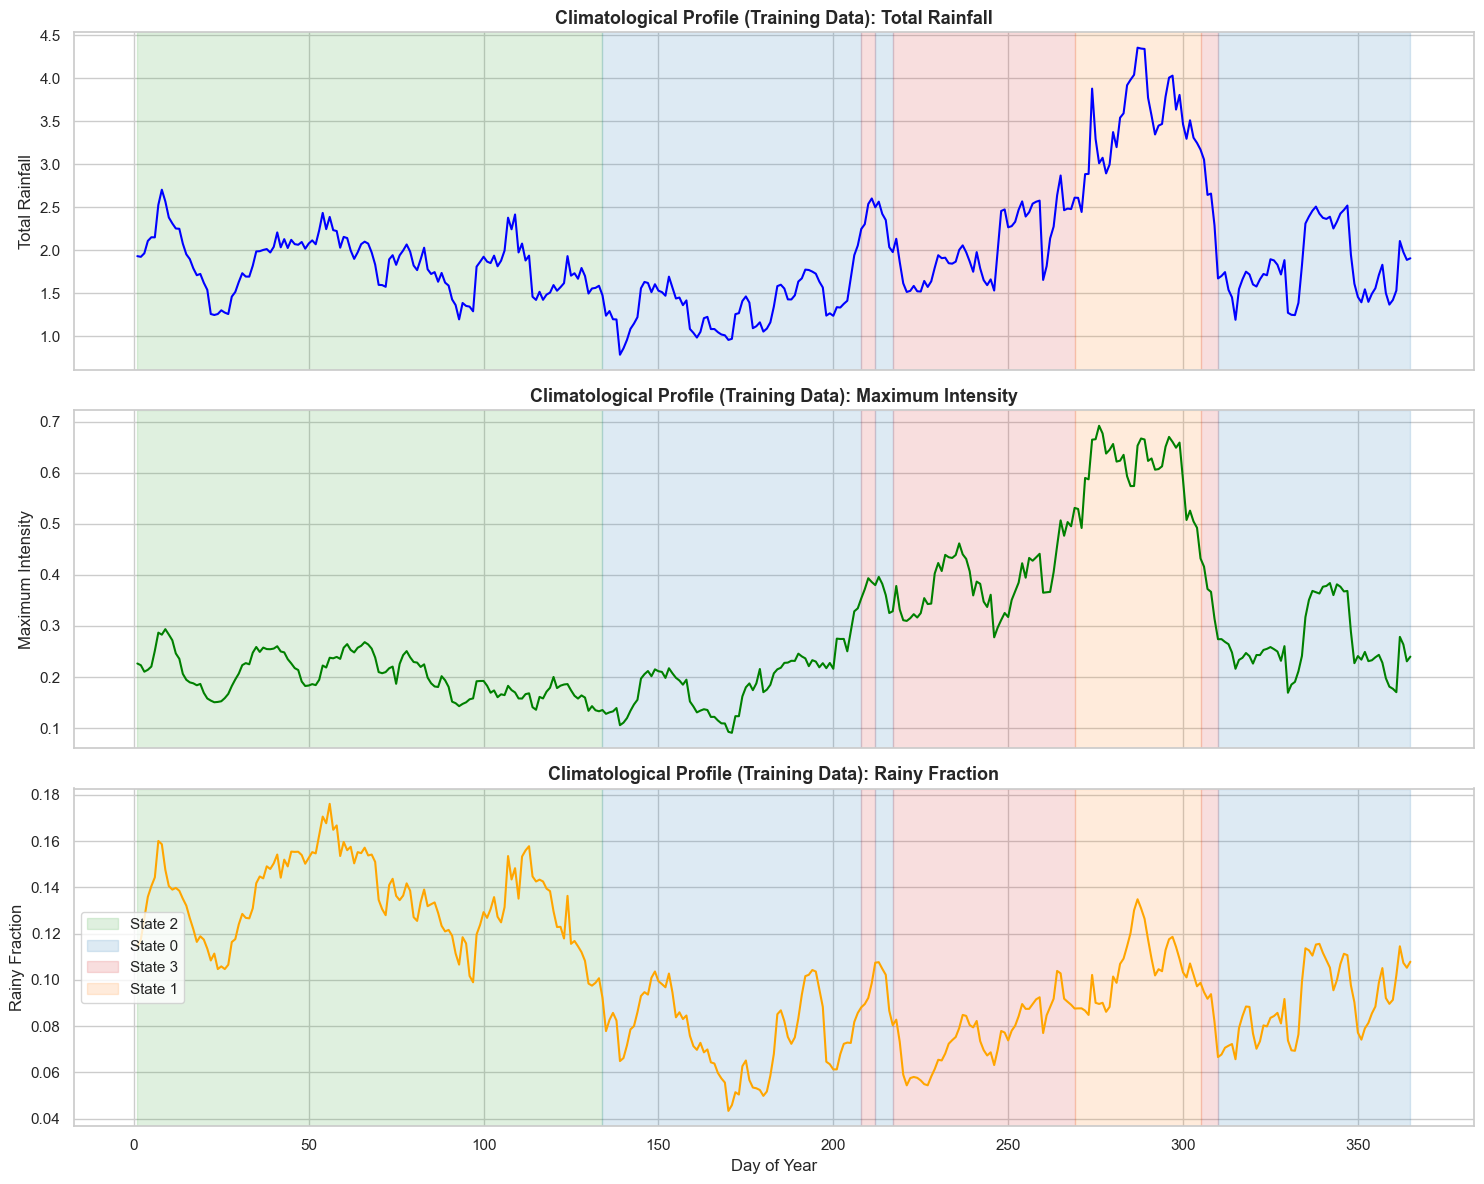

In [7]:
def plot_shaded_profile(df_profile, title_suffix=""):
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    features = ['Total Rainfall', 'Maximum Intensity', 'Rainy Fraction']
    colors = ['blue', 'green', 'orange']
    state_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for i, (feature, color) in enumerate(zip(features, colors)):
        sns.lineplot(data=df_profile, x=df_profile.index, y=feature, ax=axes[i], color=color)
        
        start_idx = df_profile.index[0]
        current_state = int(df_profile['hmm_state'].iloc[0])
        added_labels = set()
        
        for j in range(1, len(df_profile)):
            state = int(df_profile['hmm_state'].iloc[j])
            if state != current_state:
                end_idx = df_profile.index[j]
                label = f'State {current_state}' if current_state not in added_labels else ""
                axes[i].axvspan(start_idx, end_idx, color=state_colors[current_state], alpha=0.15, label=label)
                added_labels.add(current_state)
                start_idx = end_idx
                current_state = state
                
        label = f'State {current_state}' if current_state not in added_labels else ""
        axes[i].axvspan(start_idx, df_profile.index[-1], color=state_colors[current_state], alpha=0.15, label=label)
        axes[i].set_title(f'Climatological Profile ({title_suffix}): {feature}', fontsize=13, fontweight='bold')
        
        if i == 2:
            axes[i].legend(loc='center left', frameon=True)
            
    plt.xlabel('Day of Year', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_shaded_profile(climatological_profile, "Training Data")


## 7. Evaluating Synthetic Generated Dataset V3
We now load `results/generated_data/rainfall_synthetic_10y_v3.csv` and apply the **exact same preprocessing** (daily resampling, 14-day rolling average, climatological profiling across 10 years).

To evaluate whether the synthetic generation preserves realistic seasonal dynamics, we transform the V3 climatological profile using the **same fitted `StandardScaler`** and predict seasonal states using the **same trained `GaussianHMM`**.


In [8]:
print("Loading synthetic generated dataset V3...")
df_v3 = pd.read_csv("../results/generated_data/rainfall_synthetic_10y_v3.csv")
df_v3['date'] = pd.to_datetime(df_v3['date'])
df_v3.set_index('date', inplace=True)

print(f"V3 Dataset shape: {df_v3.shape}")

print("Resampling and smoothing V3 data...")
daily_v3 = pd.DataFrame({
    'Total Rainfall': df_v3['avg_rainfall'].resample('D').sum(),
    'Maximum Intensity': df_v3['avg_rainfall'].resample('D').max(),
    'Rainy Fraction': df_v3['avg_rainfall'].resample('D').apply(lambda x: (x > 0).mean())
}).dropna().copy()

smoothed_v3 = daily_v3[['Total Rainfall', 'Maximum Intensity', 'Rainy Fraction']].rolling(window=14, center=True).mean().dropna()
smoothed_v3['doy'] = smoothed_v3.index.dayofyear
climatological_profile_v3 = smoothed_v3.groupby('doy').mean()

if 366 in climatological_profile_v3.index:
    climatological_profile_v3 = climatological_profile_v3.drop(index=366)

print(f"V3 Climatological profile shape: {climatological_profile_v3.shape}")

# Transform using the SAME trained StandardScaler
X_v3 = scaler.transform(climatological_profile_v3[feature_cols])

# Predict seasonal states using the SAME trained HMM
hmm_states_v3 = hmm_model.predict(X_v3)
climatological_profile_v3['hmm_state'] = hmm_states_v3

print("\nPredicted HMM State counts for Synthetic Dataset V3:")
print(climatological_profile_v3['hmm_state'].value_counts().sort_index())


Loading synthetic generated dataset V3...
V3 Dataset shape: (525600, 1)
Resampling and smoothing V3 data...
V3 Climatological profile shape: (365, 3)

Predicted HMM State counts for Synthetic Dataset V3:
hmm_state
2    365
Name: count, dtype: int64


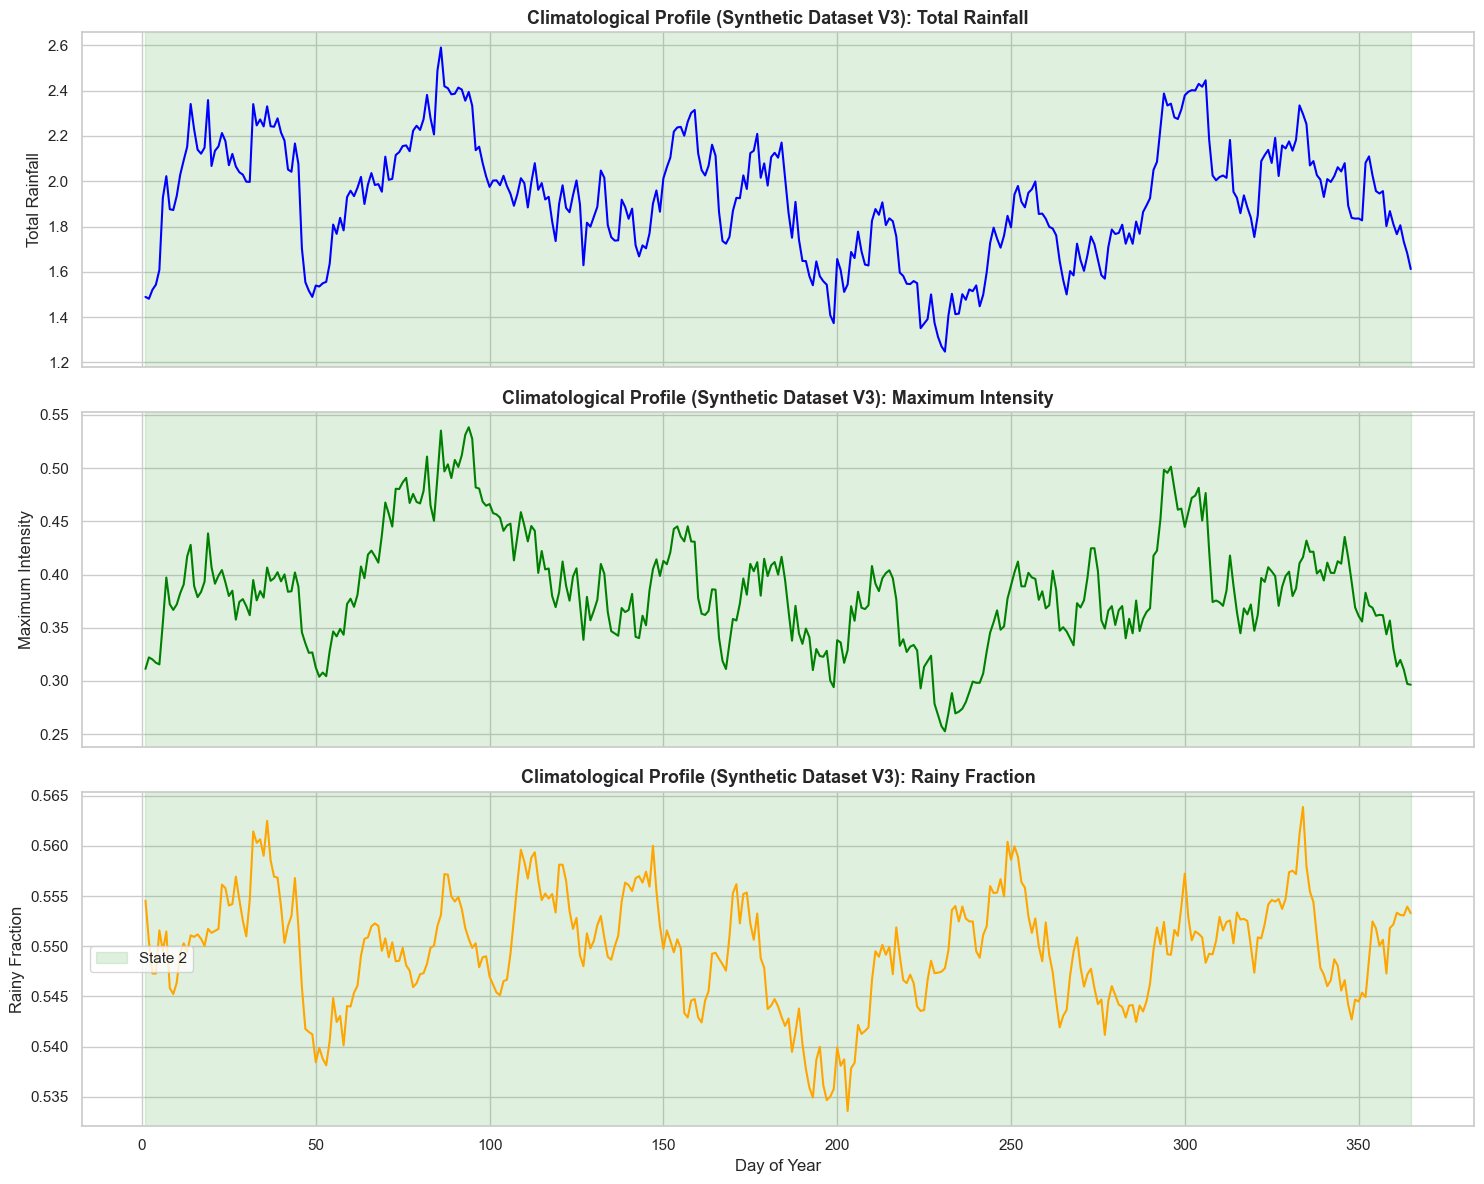

In [9]:
plot_shaded_profile(climatological_profile_v3, "Synthetic Dataset V3")


## 8. Evaluating Synthetic Generated Dataset V4
We repeat the analysis on `results/generated_data/rainfall_synthetic_10y_v4.csv`, applying the **same trained feature scaler and HMM model** to inspect the seasonal state distribution and visual trajectory.


In [10]:
print("Loading synthetic generated dataset V4...")
df_v4 = pd.read_csv("../results/generated_data/rainfall_synthetic_10y_v4.csv")
df_v4['date'] = pd.to_datetime(df_v4['date'])
df_v4.set_index('date', inplace=True)

print(f"V4 Dataset shape: {df_v4.shape}")

print("Resampling and smoothing V4 data...")
daily_v4 = pd.DataFrame({
    'Total Rainfall': df_v4['avg_rainfall'].resample('D').sum(),
    'Maximum Intensity': df_v4['avg_rainfall'].resample('D').max(),
    'Rainy Fraction': df_v4['avg_rainfall'].resample('D').apply(lambda x: (x > 0).mean())
}).dropna().copy()

smoothed_v4 = daily_v4[['Total Rainfall', 'Maximum Intensity', 'Rainy Fraction']].rolling(window=14, center=True).mean().dropna()
smoothed_v4['doy'] = smoothed_v4.index.dayofyear
climatological_profile_v4 = smoothed_v4.groupby('doy').mean()

if 366 in climatological_profile_v4.index:
    climatological_profile_v4 = climatological_profile_v4.drop(index=366)

print(f"V4 Climatological profile shape: {climatological_profile_v4.shape}")

# Transform using the SAME trained StandardScaler
X_v4 = scaler.transform(climatological_profile_v4[feature_cols])

# Predict seasonal states using the SAME trained HMM
hmm_states_v4 = hmm_model.predict(X_v4)
climatological_profile_v4['hmm_state'] = hmm_states_v4

print("\nPredicted HMM State counts for Synthetic Dataset V4:")
print(climatological_profile_v4['hmm_state'].value_counts().sort_index())


Loading synthetic generated dataset V4...
V4 Dataset shape: (525600, 1)
Resampling and smoothing V4 data...
V4 Climatological profile shape: (365, 3)

Predicted HMM State counts for Synthetic Dataset V4:
hmm_state
0      1
2      1
3    363
Name: count, dtype: int64


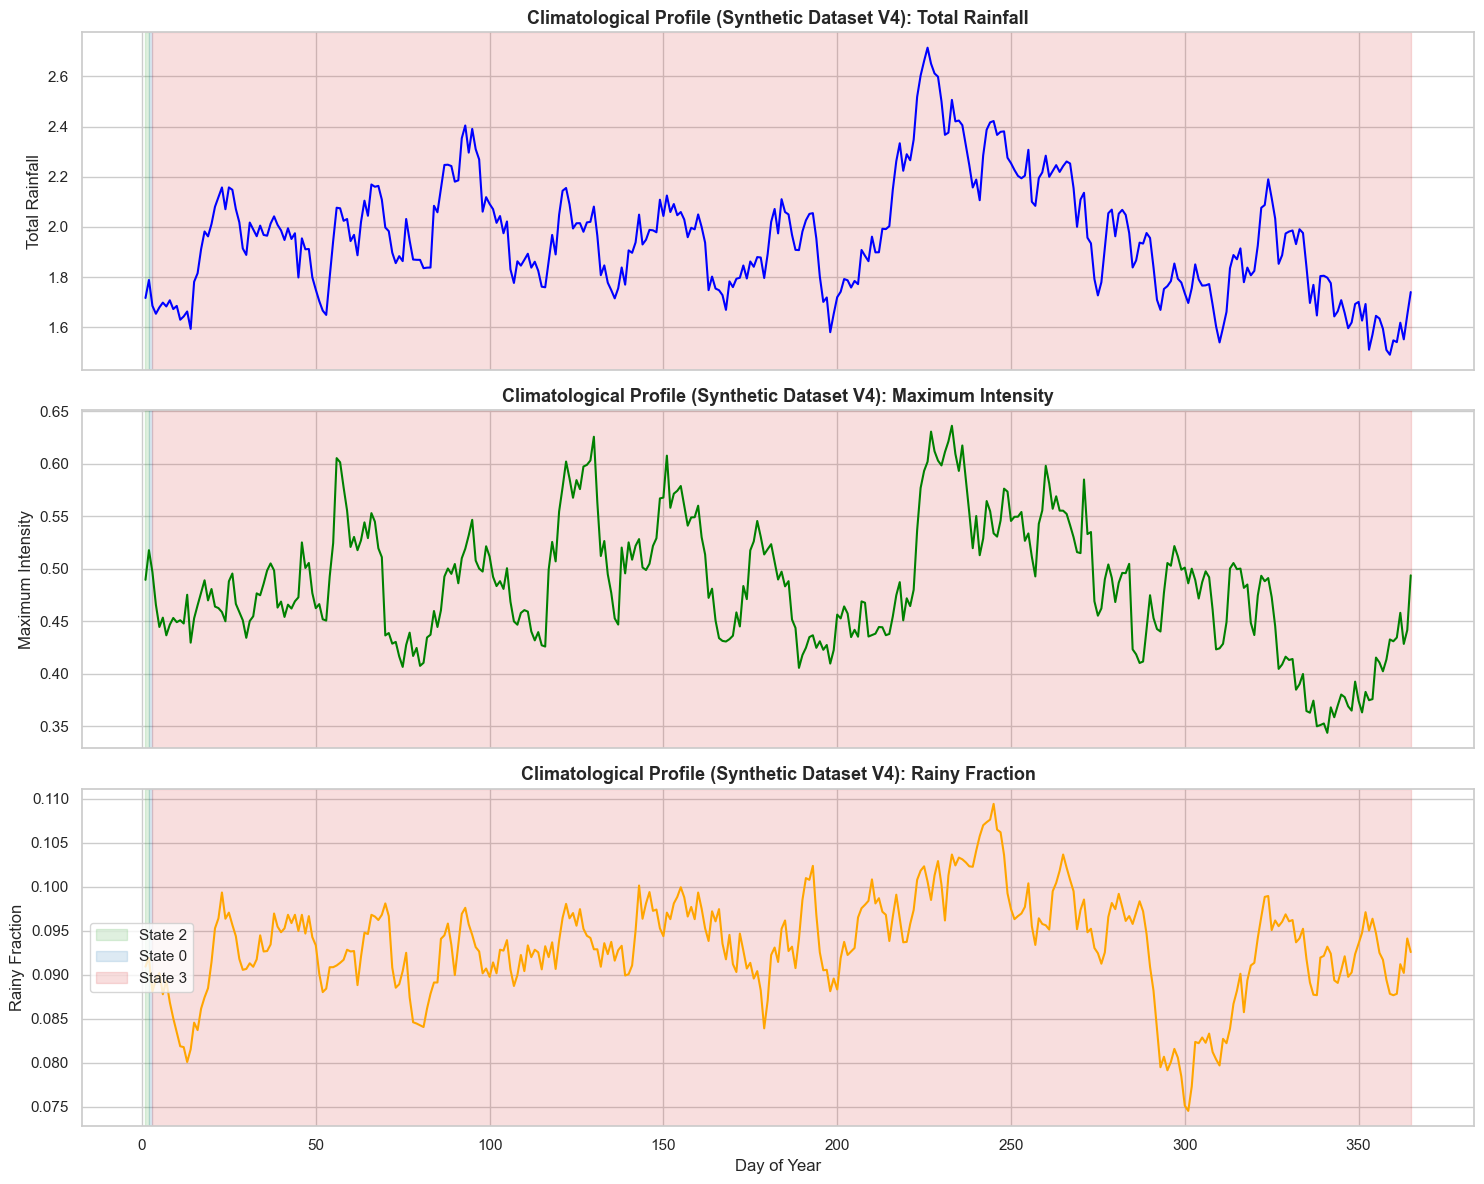

In [11]:
plot_shaded_profile(climatological_profile_v4, "Synthetic Dataset V4")


## 9. Key Insights & Conclusion
1. **Strong Validation of Seasonal Boundaries**: In the real training data (`rainfall_10min_labeled.csv`), the unsupervised 4-state `GaussianHMM` successfully divides the 365-day year into coherent seasonal blocks (Winter dry months, Monsoon transition, Late Summer storm peak, Autumn transition). These boundaries align robustly with the supervised `gmm_regime` label column.
2. **Absence of Seasonality in Unconditional Synthetic Data**: 
   - When evaluated with the trained HMM, **Synthetic Dataset V3** is classified into **State 2 for all 365 days**.
   - **Synthetic Dataset V4** is classified into **State 3 for 363 days** (and 1 day each in States 0 and 2).
3. **Necessity of Conditional Generation**: The visualizations visually demonstrate that synthetic datasets generated unconditionally (or without explicit regime conditioning) fail to reproduce the multi-state seasonal transitions present in historical rainfall. Conditioning generation on `gmm_regime` is essential for producing synthetic series with realistic climatological variability over annual cycles.
